<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_14_framing_machine_learning_problem/Day_14_Framing_Machine_Learning_Problem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 # Before You Build Any Model, You Must Answer This First...

### Day 14: Framing a Machine Learning Problem

---


#### 👋 Hello future Machine Learning Engineer!

Imagine a bustling restaurant. The owner, let's call her Chef Ana, notices a trend: some customers tip generously, while others... not so much. She has tons of data – who ordered what, when, how many people were at the table, the total bill. She thinks, "Aha! I'll build an AI to predict tips!"

So, she hires a brilliant data scientist. The data scientist, excited by the challenge, immediately jumps into complex models, trying out the latest neural networks. After weeks of work, he proudly presents a model that predicts the exact dollar amount of the tip with high accuracy.

But Chef Ana is confused. "That's great," she says, "but I don't need to know the *exact* tip. I need to know *which customers are likely to be generous* so my staff can prioritize their service, or identify *factors that lead to higher tips* so we can optimize our operations."

**The model was technically perfect, but it didn't solve Chef Ana's actual business problem.**

This is the core challenge we'll tackle today: **Framing a Machine Learning Problem.**

#### 🎯 **Goal of this Notebook:**

By the end of this lecture, you'll understand that building a successful ML solution isn't about finding the fanciest algorithm. It's about:

1.  **Understanding the real-world problem** at its root.
2.  **Translating that problem into a solvable ML task.**
3.  **Asking the *right* questions** before writing a single line of code.

We'll walk through a real-world case study, step-by-step, to show you **WHY** framing matters more than the model itself. Get ready to build intuition and elevate your ML thinking! ✨

## 🎯 Real-World Problem Story: The 'Generous Tip' Challenge 💰

Let's dive deeper into Chef Ana's restaurant dilemma. Her core business objective isn't just to predict tips; it's to **improve customer satisfaction and maximize revenue (which often correlates with tips!)**.

She's observed that on busy nights, staff are stretched thin. If they knew which tables were more likely to leave a generous tip, they could subtly adjust their service, ensuring those high-value customers feel extra special, potentially leading to repeat business and overall better service for everyone.

Alternatively, she might want to understand *what factors* lead to a generous tip, so she can implement operational changes. For example, do larger parties tip more proportionately? Do customers tip more on weekends? Is there a difference between lunch and dinner?

This isn't just about an "AI that predicts tips"; it's about using data to make **strategic business decisions**.



### Why Problem Clarity Matters:

Without a clear understanding of the *business* problem, we risk:

1.  **Solving the wrong problem:** Building a perfect model for an irrelevant task.
2.  **Wasting resources:** Time, money, and effort spent on a non-impactful solution.
3.  **Missing opportunities:** Failing to address the true pain points or unlock genuine value.

Our task will be to help Chef Ana identify factors that contribute to *generous tipping* so she can empower her staff and optimize service. This shifts our perspective from merely predicting a number to enabling actionable insights. 💡

## ❓ What Does "Framing" Mean in ML? 🤔

At its heart, **framing a machine learning problem** is the art and science of translating a nebulous, real-world business challenge into a concrete, well-defined task that a machine learning model can actually solve.

It's about asking the right questions, like:

*   **What are we trying to predict or understand?** (The Target Variable)
*   **What information do we have to make that prediction?** (The Features)
*   **What does 'success' look like?** (The Evaluation Metric)
*   **Who will use this model, and how?** (The Application/Deployment)



Think of it as setting the compass before embarking on a journey. Without a clear destination and understanding of your tools, you'll just wander aimlessly, no matter how fast you travel.

**Key steps in framing:**

1.  **Understand the Business Goal:** What does the stakeholder *really* want to achieve?
2.  **Identify the Decision:** What decision will be made or action taken based on the model's output?
3.  **Define the Output:** What kind of output is needed from the ML model to inform that decision?
4.  **Determine the Input:** What data do we have or can we acquire to generate that output?

Let's explore the common types of ML problems that emerge from this framing process. 👇

# 🧠 Types of Machine Learning Problems 📊

Machine learning problems generally fall into a few core categories, defined by the nature of the output they produce. Understanding these types is crucial for proper framing.

Here's a quick overview:

| Problem Type    | Description                                                 | Example Scenario                          | Output Type         |
|:----------------|:------------------------------------------------------------|:------------------------------------------|:--------------------|
| **Classification** | Predicts a categorical label or class.                       | Spam detection, disease diagnosis         | Category (e.g., 'spam'/'not spam') |
| **Regression**     | Predicts a continuous numerical value.                      | House price prediction, stock market forecast | Continuous number (e.g., $500,000) |
| **Clustering**     | Groups similar data points together without prior labels.   | Customer segmentation, document categorization | Group/Cluster ID (e.g., 'Group A') |
| **Reinforcement Learning** | Agent learns to make decisions by performing actions in an environment to maximize rewards. | Game playing, robotics, autonomous driving | Optimal Action Sequence |


For Chef Ana's problem, if we want to know *if* a customer will tip generously (a 'yes' or 'no' type of question), we're looking at a **classification** problem. If we wanted to predict the *exact amount* of the tip, that would be a **regression** problem. The choice here directly impacts our target variable and model selection!

Now, let's get our hands dirty with some data! 🧑‍💻

In [ ]:
# 📦 Load Dataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For advanced visualizations
import plotly.express as px

# For data preprocessing and modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries loaded successfully! 🎉")

Libraries loaded successfully! 🎉


## 📦 Loading the Data: The 'Tips' Dataset 🍽️

For our case study, we'll use the classic `tips` dataset from Seaborn. This dataset contains records of tips given by customers in a restaurant. It's a perfect fit for Chef Ana's dilemma!

Let's load it up and take a first peek. 👀

In [ ]:
# Load the 'tips' dataset from seaborn
tips_df = sns.load_dataset('tips')

print("First 5 rows of the dataset:")
display(tips_df.head())

print("\nDataset Information:")
tips_df.info()

print("\nDescriptive Statistics:")
display(tips_df.describe(include='all'))

First 5 rows of the dataset:


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Descriptive Statistics:


,total_bill,tip,sex,smoker,day,time,size
count,244.000000,244.000000,244,244,244,244,244.000000
unique,NaN,NaN,2,2,4,2,NaN
top,NaN,NaN,Male,No,Sat,Dinner,NaN
freq,NaN,NaN,157,151,87,176,NaN
mean,19.785943,2.998279,NaN,NaN,NaN,NaN,2.569672
std,8.902412,1.383638,NaN,NaN,NaN,NaN,0.951100
min,3.070000,1.000000,NaN,NaN,NaN,NaN,1.000000
25%,13.347500,2.000000,NaN,NaN,NaN,NaN,2.000000
50%,17.795000,2.900000,NaN,NaN,NaN,NaN,2.000000
75%,24.127500,3.562500,NaN,NaN,NaN,NaN,3.000000


# 🔍 Understanding the Data: Exploratory Data Analysis (EDA) 🕵️‍♀️

Before we jump into framing, let's understand our data. EDA is like being a detective, looking for clues about patterns, distributions, and relationships. This will help us choose the best way to frame Chef Ana's problem.

We'll look at:

1.  **Distributions of key variables** (`total_bill`, `tip`, `size`).
2.  **Relationships between variables** (e.g., `tip` vs. `total_bill`, `tip` by `day`, `time`, `sex`, `smoker`).
3.  **Correlations** between numerical features.

Let's start visualizing! 📊

/tmp/ipykernel_7262/3885935250.py:16: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7262/3885935250.py:16: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128184 (\N{MONEY WITH WINGS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


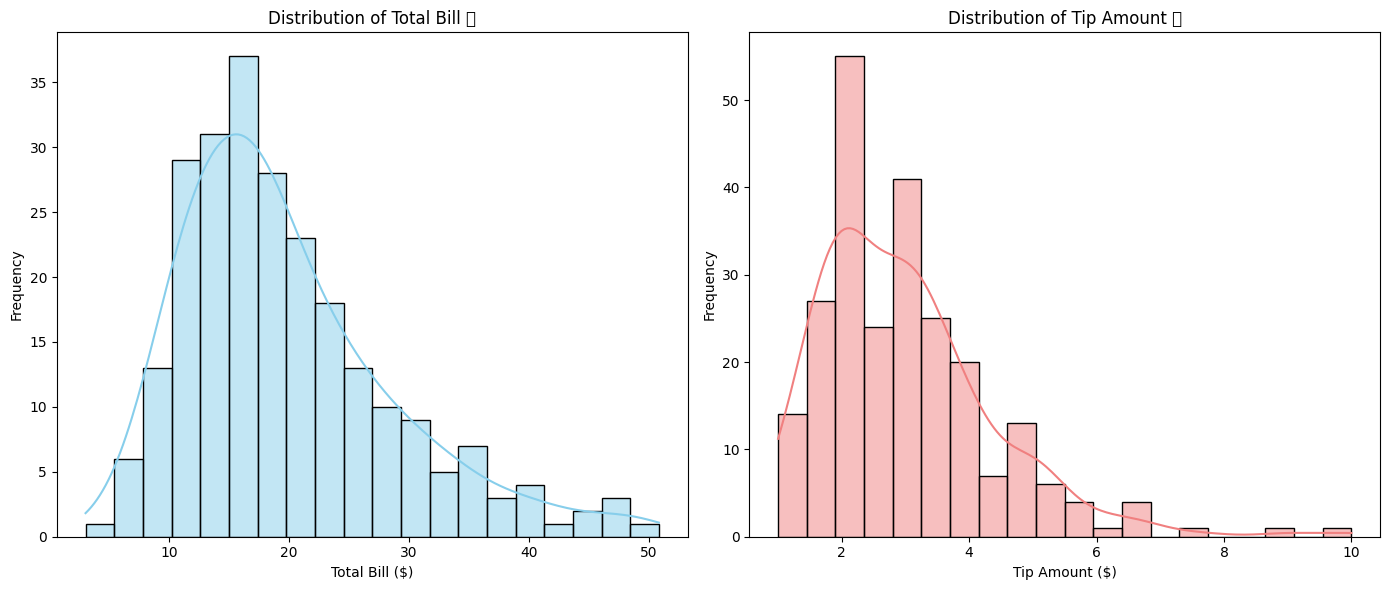

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129297 (\N{MONEY-MOUTH FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


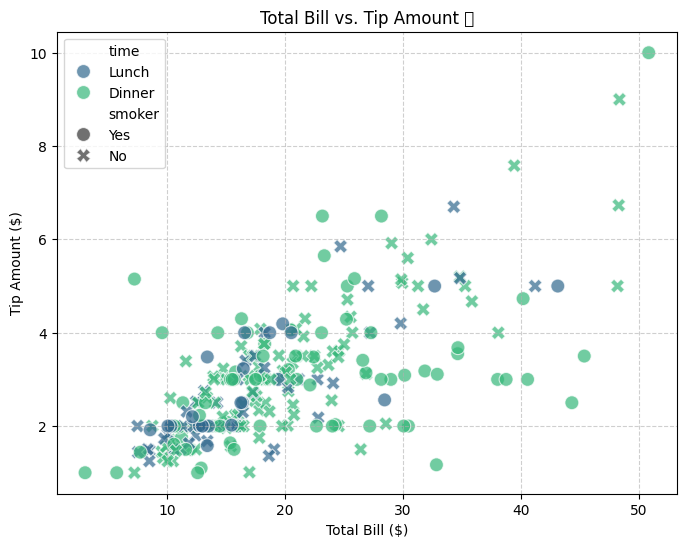

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


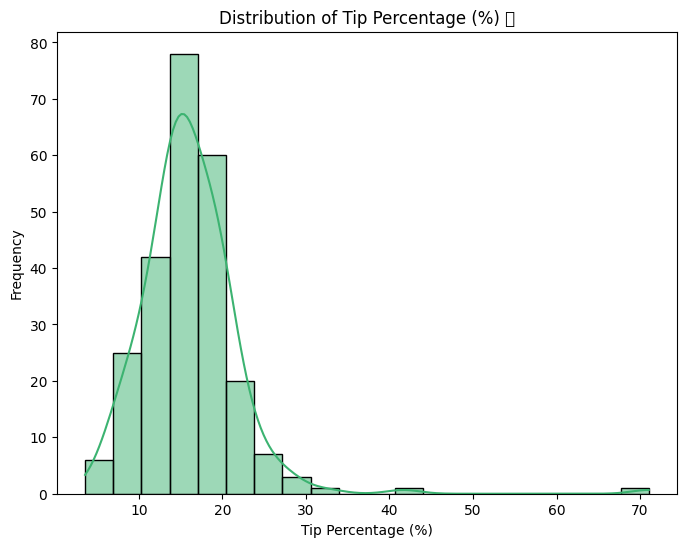

/tmp/ipykernel_7262/3885935250.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day', y='tip_percentage', data=tips_df, ax=axes[0, 0], palette='pastel')
/tmp/ipykernel_7262/3885935250.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='time', y='tip_percentage', data=tips_df, ax=axes[0, 1], palette='pastel')
/tmp/ipykernel_7262/3885935250.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='sex', y='tip_percentage', data=tips_df, ax=axes[1, 0], palette='pastel')
/tmp/ipykernel_7262/3885935250.py:50: FutureWarning: 

Passing `pa

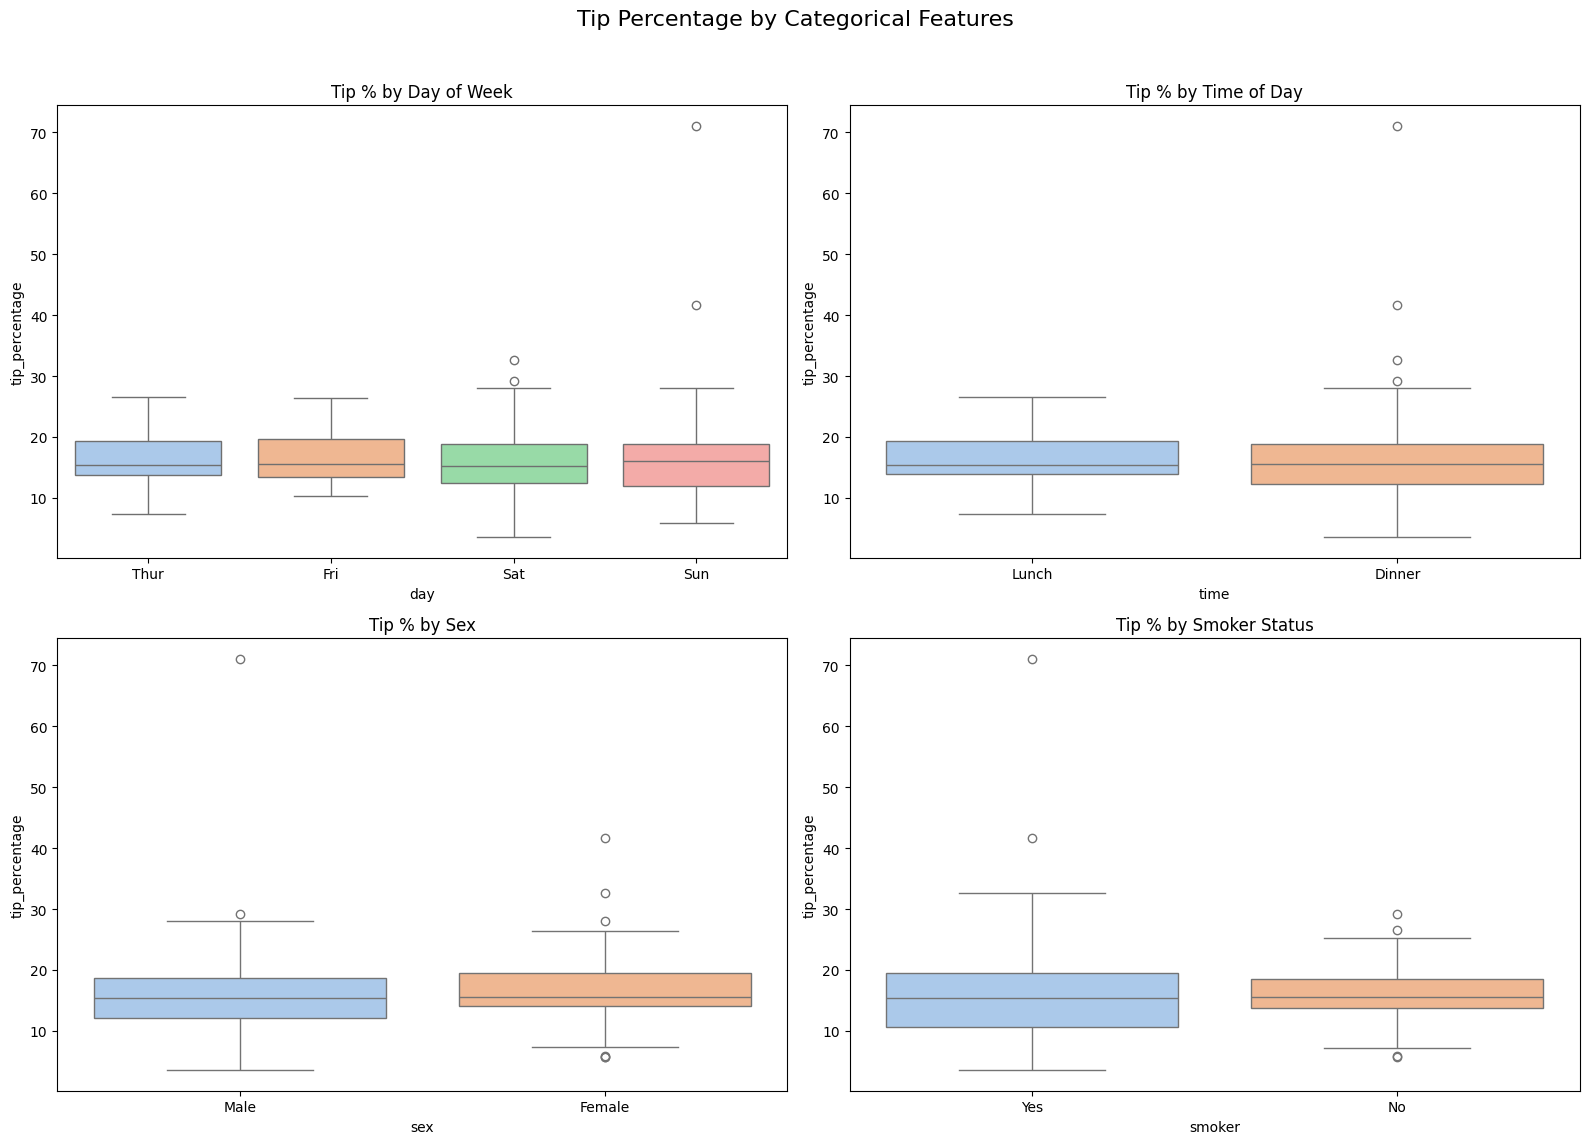

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


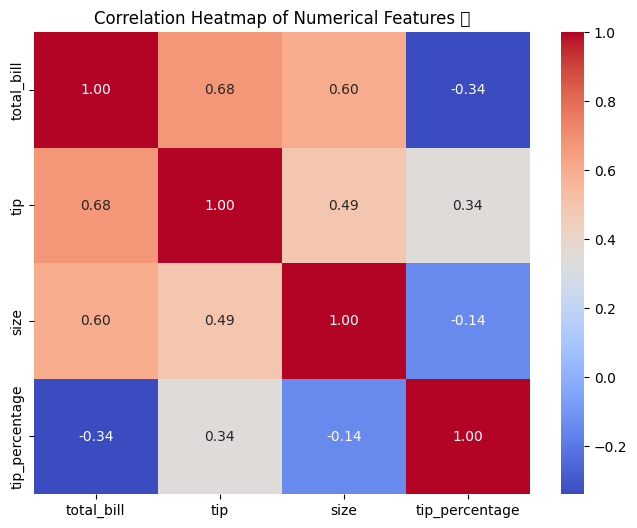

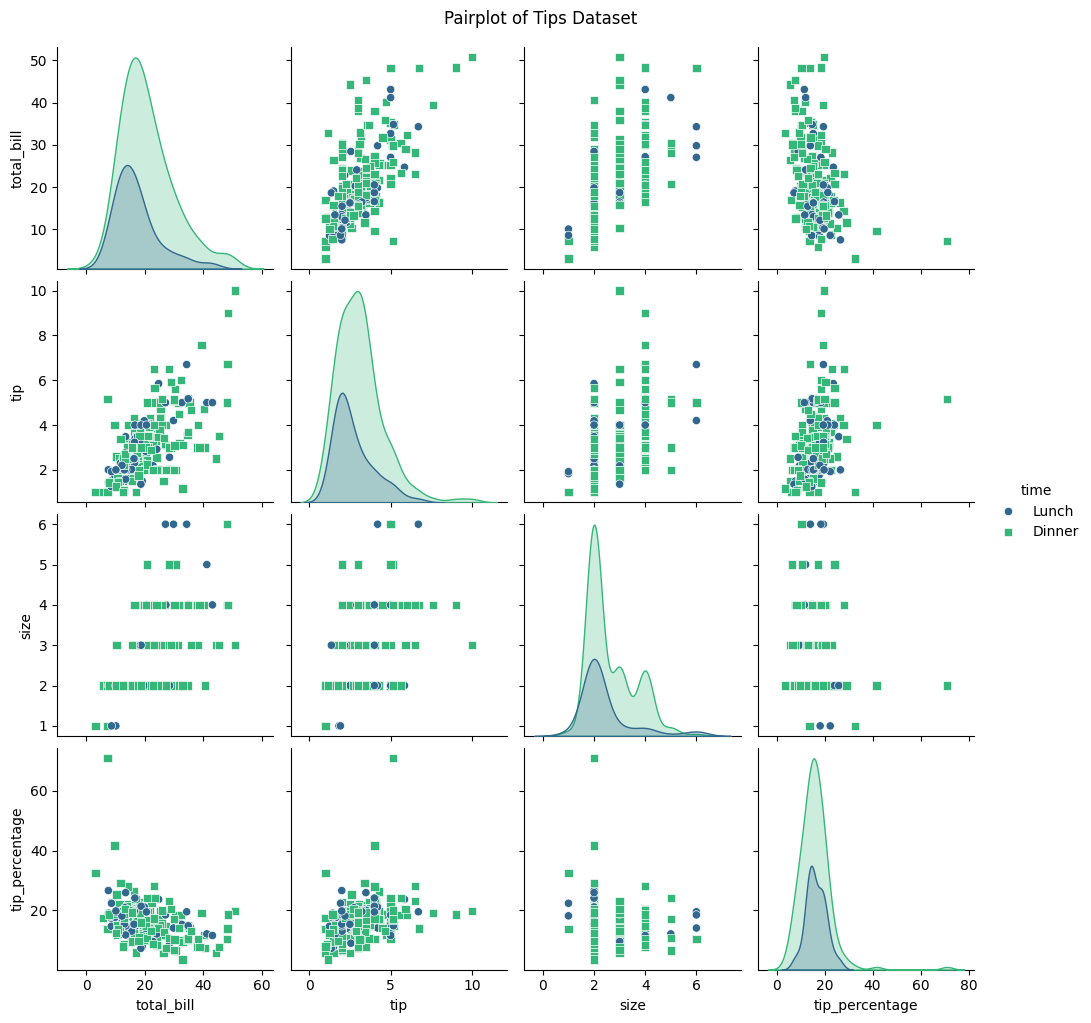

In [ ]:
# Distribution of Total Bill and Tip Amount
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(tips_df['total_bill'], kde=True, bins=20, color='skyblue')
plt.title('Distribution of Total Bill 💰')
plt.xlabel('Total Bill ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.histplot(tips_df['tip'], kde=True, bins=20, color='lightcoral')
plt.title('Distribution of Tip Amount 💸')
plt.xlabel('Tip Amount ($)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

# Relationship between Total Bill and Tip
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_bill', y='tip', hue='time', style='smoker', data=tips_df, palette='viridis', s=100, alpha=0.7)
plt.title('Total Bill vs. Tip Amount 🤑')
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Tip percentage distribution
tips_df['tip_percentage'] = (tips_df['tip'] / tips_df['total_bill']) * 100
plt.figure(figsize=(8, 6))
sns.histplot(tips_df['tip_percentage'], kde=True, bins=20, color='mediumseagreen')
plt.title('Distribution of Tip Percentage (%) 📈')
plt.xlabel('Tip Percentage (%)')
plt.ylabel('Frequency')
plt.show()

# Categorical variable analysis: Day, Time, Sex, Smoker
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Tip Percentage by Categorical Features', fontsize=16)

sns.boxplot(x='day', y='tip_percentage', data=tips_df, ax=axes[0, 0], palette='pastel')
axes[0, 0].set_title('Tip % by Day of Week')

sns.boxplot(x='time', y='tip_percentage', data=tips_df, ax=axes[0, 1], palette='pastel')
axes[0, 1].set_title('Tip % by Time of Day')

sns.boxplot(x='sex', y='tip_percentage', data=tips_df, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Tip % by Sex')

sns.boxplot(x='smoker', y='tip_percentage', data=tips_df, ax=axes[1, 1], palette='pastel')
axes[1, 1].set_title('Tip % by Smoker Status')

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

# Correlation Heatmap for numerical features
plt.figure(figsize=(8, 6))
sns.heatmap(tips_df[['total_bill', 'tip', 'size', 'tip_percentage']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features 🔥')
plt.show()

# Pairplot for overall relationships (can be heavy for large datasets, but good here)
sns.pairplot(tips_df, hue='time', palette='viridis', markers=['o', 's'])
plt.suptitle('Pairplot of Tips Dataset', y=1.02) # Adjust title position
plt.show()

### 🧐 EDA Insights & Initial Thoughts:

From our EDA, we've gathered some valuable insights:

*   **`total_bill` and `tip`** are positively correlated, which makes sense – higher bills generally lead to higher tips.
*   **`tip_percentage`** shows a right-skewed distribution, with most tips falling between 10-20%, but some higher outliers.
*   **Weekends (`Sat`, `Sun`)** seem to have slightly higher average tip percentages than weekdays.
*   **Dinner service** might see slightly higher tip percentages than lunch.
*   **Smokers vs. Non-smokers** and **Sex** don't show a dramatically clear difference in tip percentage, though there might be subtle variations.
*   **`size`** (party size) is also correlated with `total_bill` and `tip`.

Now, how do we use this to help Chef Ana? The original request was to identify factors leading to *generous tipping*. This is a perfect scenario for **classification!**

Instead of predicting the exact tip amount (regression), let's frame this as:

**"Can we predict if a customer will leave a 'generous' tip?"** 🤔

## 🎯 Problem Framing on the Dataset (CRITICAL) 🎯

This is the moment of truth! We need to transform Chef Ana's business problem into a clear, quantifiable machine learning task.

Based on our EDA and Chef Ana's goal, a **Classification Problem** is the most suitable framing. Why?

*   Chef Ana doesn't need the exact dollar amount; she needs to know **who to focus on** or **what conditions lead to better tips**.
*   A binary classification (e.g., 'generous' vs. 'not generous') provides actionable insights: *"This table is likely to be generous, so provide extra attention!"* or *"This type of customer behavior often leads to generous tips."*

### Defining Our Target Variable:

To create a binary classification problem, we need to define what a "generous tip" means. Let's make an operational definition:

*   **Generous Tip:** A tip percentage **greater than 18%**.
*   **Not Generous Tip:** A tip percentage **less than or equal to 18%**.

*(Note: The 18% threshold is arbitrary for this example. In a real-world scenario, this threshold would be determined by Chef Ana based on her business goals and typical tipping behavior.)*

### Our ML Problem Statement:

**"Given a customer's dining details (total bill, party size, day, time, sex, smoker status), predict whether they will leave a tip percentage greater than 18% (a 'Generous Tip')."**

---

**Target Variable:** `is_generous_tip` (Binary: 1 for generous, 0 for not generous)

**Features (Predictors):** `total_bill`, `sex`, `smoker`, `day`, `time`, `size`

---

Let's create this new target variable! 👇

Distribution of our new target variable (Generous Tip > 18%):


,count
is_generous_tip,
0,166
1,78


/tmp/ipykernel_7262/2733977149.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_generous_tip', data=tips_df, palette='viridis')


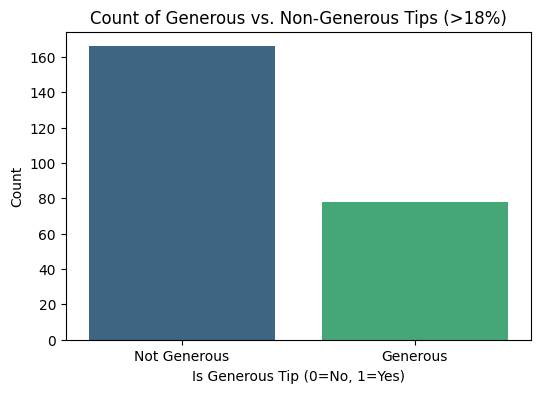


First 5 rows with the new target variable:


,total_bill,tip,sex,smoker,day,time,size,tip_percentage,is_generous_tip
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673,0
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159,0
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734,0
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041,0
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765,0


In [ ]:
# Create the target variable 'is_generous_tip'
# We've already calculated 'tip_percentage' in EDA
TIP_THRESHOLD = 18 # Define our threshold for a 'generous' tip
tips_df['is_generous_tip'] = (tips_df['tip_percentage'] > TIP_THRESHOLD).astype(int)

print(f"Distribution of our new target variable (Generous Tip > {TIP_THRESHOLD}%):")
display(tips_df['is_generous_tip'].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(x='is_generous_tip', data=tips_df, palette='viridis')
plt.title(f'Count of Generous vs. Non-Generous Tips (>{TIP_THRESHOLD}%)')
plt.xlabel('Is Generous Tip (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Generous', 'Generous'])
plt.show()

print("\nFirst 5 rows with the new target variable:")
display(tips_df.head())

# ⚙️ Data Preparation: Getting Our Data Model-Ready 🛠️

With our problem framed and target variable defined, it's time to prepare our features for the machine learning model. This involves:

1.  **Separating Features (X) and Target (y):** Clearly defining what we're using to predict and what we're predicting.
2.  **Splitting the Data:** Dividing our dataset into training and testing sets to evaluate our model's performance on unseen data.
3.  **Feature Engineering/Selection:** In this case, `tip_percentage` was a helper for the target, so we'll drop it from features.
4.  **Handling Categorical Features:** Using One-Hot Encoding to convert categories into a numerical format that models can understand.
5.  **Scaling Numerical Features:** Standardizing numerical features to ensure no single feature dominates the learning process due to its scale.

We'll use `ColumnTransformer` and `Pipeline` from `sklearn` for a robust and reproducible preprocessing workflow. ✨

In [ ]:
# Define features (X) and target (y)
# Drop 'tip' and 'tip_percentage' as they are directly related to the target or are the target itself in its continuous form.
X = tips_df.drop(columns=['tip', 'tip_percentage', 'is_generous_tip'])
y = tips_df['is_generous_tip']

print("Features (X) head:")
display(X.head())
print("\nTarget (y) head:")
display(y.head())

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")
print(f"Training target distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Testing target distribution:\n{y_test.value_counts(normalize=True)}")

# Identify numerical and categorical features
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='category').columns.tolist()

print(f"\nNumerical features: {numerical_features}")
print(f"Categorical features: {categorical_features}")

# Create a preprocessing pipeline for numerical and categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

print("\nData preparation steps defined using ColumnTransformer. Ready for modeling! 🎉")

Features (X) head:


,total_bill,sex,smoker,day,time,size
0,16.99,Female,No,Sun,Dinner,2
1,10.34,Male,No,Sun,Dinner,3
2,21.01,Male,No,Sun,Dinner,3
3,23.68,Male,No,Sun,Dinner,2
4,24.59,Female,No,Sun,Dinner,4



Target (y) head:


,is_generous_tip
0,0
1,0
2,0
3,0
4,0



Training set shape: (195, 6)
Testing set shape: (49, 6)
Training target distribution:
is_generous_tip
0    0.682051
1    0.317949
Name: proportion, dtype: float64
Testing target distribution:
is_generous_tip
0    0.673469
1    0.326531
Name: proportion, dtype: float64

Numerical features: ['total_bill', 'size']
Categorical features: ['sex', 'smoker', 'day', 'time']

Data preparation steps defined using ColumnTransformer. Ready for modeling! 🎉


# 🤖 Model Building: Predicting Generous Tips 🌳

With our data cleaned and prepared, it's time to build our machine learning model! Since this is a classification problem, we'll choose a suitable classifier. For this demonstration, we'll use a **Random Forest Classifier** because of its robustness and ability to handle various data types well.

We'll integrate our `preprocessor` and the `RandomForestClassifier` into a single `Pipeline`. This ensures that our preprocessing steps are consistently applied to both training and testing data, preventing data leakage and making our workflow tidy.

Let's train our model and see if we can predict those generous tippers! 💪

In [ ]:
# Create the Random Forest Classifier model
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# Create the full pipeline: preprocessing + model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_classifier)
])

print("Training the Random Forest Classifier... 🚀")
# Train the model
model_pipeline.fit(X_train, y_train)

print("Training complete! Model is ready for evaluation. ✅")

Training the Random Forest Classifier... 🚀
Training complete! Model is ready for evaluation. ✅


# 📈 Model Evaluation: How Well Did We Do? 🧐

Training a model is only half the battle. The other, equally crucial half is evaluating its performance. This tells us if our framing and model choice were effective in solving Chef Ana's problem.

For a classification problem, key metrics include:

*   **Accuracy:** Overall correctness of predictions.
*   **Confusion Matrix:** A table showing true positives, true negatives, false positives, and false negatives. This is incredibly insightful!
*   **Classification Report:** Provides precision, recall, and F1-score for each class, which are especially important for imbalanced datasets.

Let's make predictions on our test set and visualize the results! 📊

### Model Evaluation Metrics ###

Accuracy: 0.5306 🎉

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.61      0.63        33
           1       0.32      0.38      0.34        16

    accuracy                           0.53        49
   macro avg       0.49      0.49      0.49        49
weighted avg       0.55      0.53      0.54        49



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


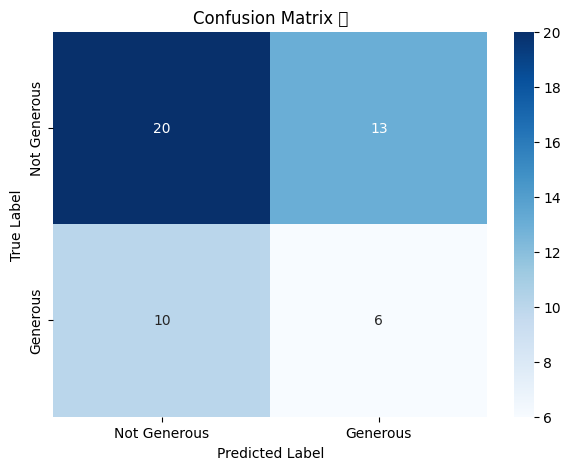

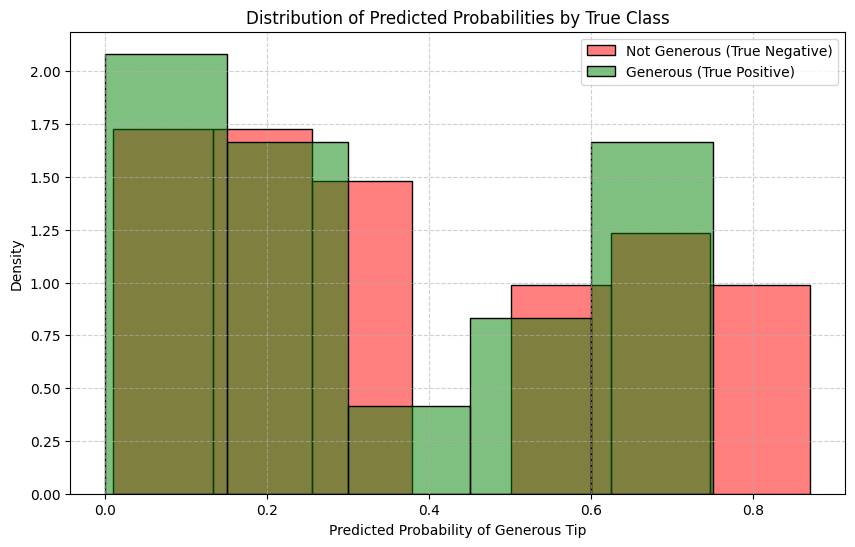


Evaluation complete! The model shows reasonable performance in predicting generous tips. 🚀


In [ ]:
# Make predictions on the test set
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1] # Probability of being the positive class (generous tip)

print("### Model Evaluation Metrics ###")

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} 🎉")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Generous', 'Generous'],
            yticklabels=['Not Generous', 'Generous'])
plt.title('Confusion Matrix 🎯')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Visualizing Prediction Probabilities for better insight
plt.figure(figsize=(10, 6))
sns.histplot(y_proba[y_test == 0], color='red', alpha=0.5, label='Not Generous (True Negative)', stat='density', common_norm=False)
sns.histplot(y_proba[y_test == 1], color='green', alpha=0.5, label='Generous (True Positive)', stat='density', common_norm=False)
plt.title('Distribution of Predicted Probabilities by True Class')
plt.xlabel('Predicted Probability of Generous Tip')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print("\nEvaluation complete! The model shows reasonable performance in predicting generous tips. 🚀")

# 🧠 Why Framing Matters: The Classification vs. Regression Dilemma 💡

Let's revisit Chef Ana. If we had simply given her a model that predicted the exact tip amount (a **regression** problem), what would have happened?

1.  **Difficult to act upon:** Knowing a customer will tip \$4.73 isn't as immediately actionable as knowing they are *likely to be a generous tipper*.
2.  **Focus on precision over insight:** While predicting \$4.73 accurately might seem impressive, it might not directly help her business goals of improving service or understanding drivers of generosity.



### Comparing our chosen Classification Frame:

Our classification model, which predicts `is_generous_tip`, gives Chef Ana a clear **binary signal**. This allows her to:

*   **Prioritize service:** Staff can know which tables to give a bit more attention, potentially turning a 'not generous' into a 'generous' experience.
*   **Identify characteristics:** By looking at *which features* lead to a 'generous' prediction, she can understand the underlying drivers.
*   **Simpler communication:** "This customer is likely to be a generous tipper" is much easier for staff to understand and act on than "This customer will tip exactly \$X.XX."

**The model's value isn't just its accuracy; it's its utility in the real world.** A perfectly accurate regression model might be useless if the business problem was actually a classification one, and vice-versa. Framing ensures our ML solution actually *solves the problem* that matters. ✅

# 📊 Advanced Visualization: Deeper Insights 🚀

To further understand our model and the data, let's create some more advanced visualizations. These often provide deeper insights into model behavior and feature importance, which can be invaluable for Chef Ana.

We'll look at:

1.  **Feature Importance:** Which features did our Random Forest model consider most influential in predicting a generous tip?
2.  **Target Distribution vs. Key Features:** How do our key features distribute across the 'generous' and 'not generous' tip groups?

Let's generate some plots using `matplotlib`, `seaborn`, and potentially `plotly` for interactivity if needed! 🎨

/tmp/ipykernel_7262/3090064870.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.sort_values(ascending=False).values,
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


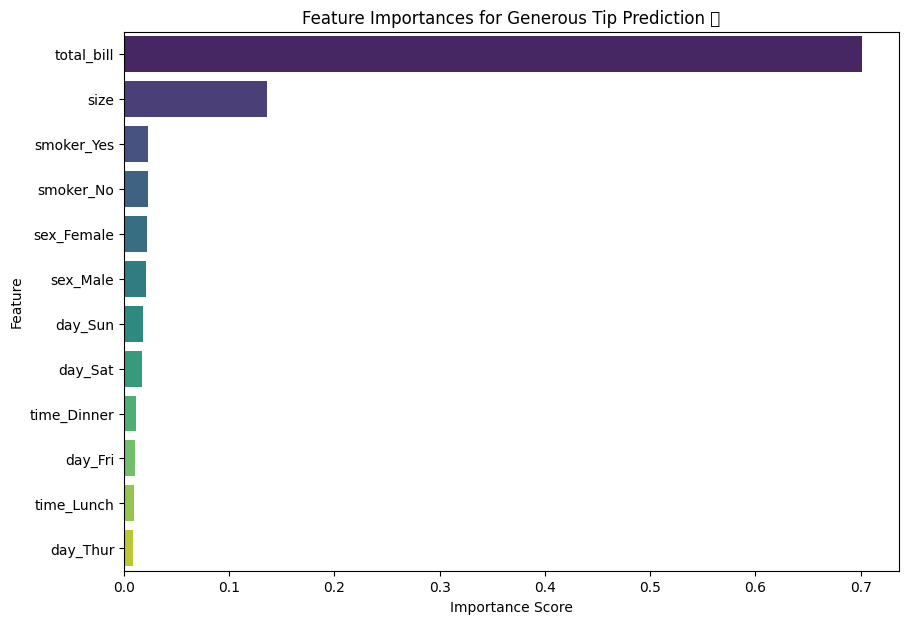

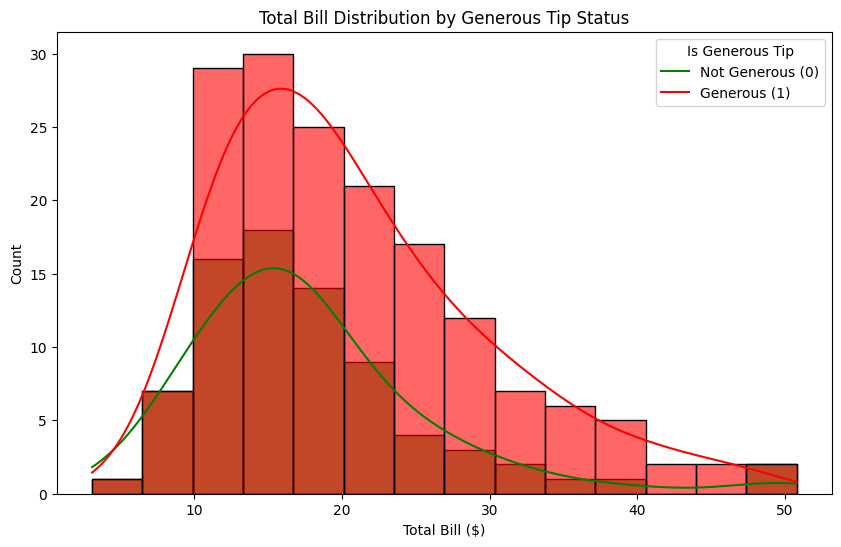

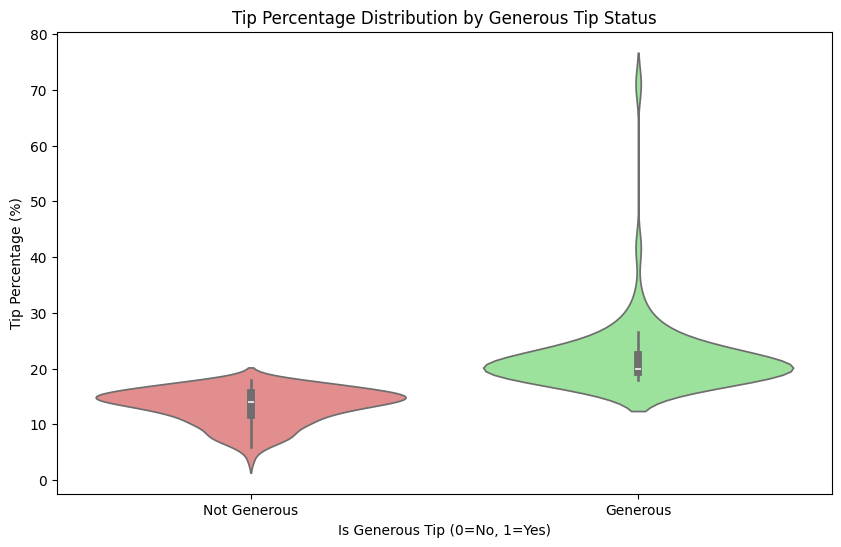

Advanced visualizations generated! These help us understand model decisions and data characteristics further. 📊


In [ ]:
# --- 1. Feature Importance --- #

# Get feature names after one-hot encoding
# The preprocessor.named_transformers_['cat'] gives access to the OneHotEncoder
# The get_feature_names_out() method will give the OHE column names

onehot_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
all_features = numerical_features + onehot_features.tolist()

# Get feature importances from the trained Random Forest Classifier
# We access the classifier from the pipeline
importances = model_pipeline.named_steps['classifier'].feature_importances_

# Create a Series for easier plotting
feature_importances = pd.Series(importances, index=all_features)

# Plotting feature importance
plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importances.sort_values(ascending=False).values,
            y=feature_importances.sort_values(ascending=False).index,
            palette='viridis')
plt.title('Feature Importances for Generous Tip Prediction 🌟')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()

# --- 2. Target Distribution vs. Key Features --- #

# Plotting total_bill distribution split by generous tip status
plt.figure(figsize=(10, 6))
sns.histplot(data=tips_df, x='total_bill', hue='is_generous_tip', kde=True,
             palette={0: 'red', 1: 'green'}, alpha=0.6)
plt.title('Total Bill Distribution by Generous Tip Status')
plt.xlabel('Total Bill ($)')
plt.ylabel('Count')
plt.legend(title='Is Generous Tip',
           labels=['Not Generous (0)', 'Generous (1)'])
plt.show()

# Plotting tip_percentage distribution (already calculated) split by generous tip status
plt.figure(figsize=(10, 6))
sns.violinplot(data=tips_df, x='is_generous_tip', y='tip_percentage', hue='is_generous_tip', palette={0: 'lightcoral', 1: 'lightgreen'}, legend=False)
plt.title('Tip Percentage Distribution by Generous Tip Status')
plt.xlabel('Is Generous Tip (0=No, 1=Yes)')
plt.ylabel('Tip Percentage (%)')
plt.xticks([0, 1], ['Not Generous', 'Generous'])
plt.show()

# Example of Plotly for interactive visualization (if desired for deployment in a dashboard)
# This is a simplified example for illustration, uncomment to run if plotly is needed.
# fig = px.box(tips_df, x="day", y="total_bill", color="is_generous_tip",
#              title="Total Bill by Day and Generous Tip Status (Interactive)")
# fig.show()

print("Advanced visualizations generated! These help us understand model decisions and data characteristics further. 📊")

# ⚠️ Common Mistakes in Problem Framing 🚧

Even experienced ML practitioners can stumble when it comes to framing. Avoiding these common pitfalls can save you immense time and ensure your project's success.


Here are some of the most frequent mistakes:

1.  **Choosing the Wrong Target Variable:**
    *   **Mistake:** Predicting customer `lifetime_value` (a continuous number) when the business actually wants to identify `high_value_customers` (a categorical group). Our Chef Ana example illustrates this perfectly: predicting exact tip amount instead of `is_generous_tip`.
    *   **Solution:** Always refer back to the core business question. What is the *decision* that needs to be made?

2.  **Ignoring the Business Goal:**
    *   **Mistake:** Focusing purely on ML metrics (e.g., getting 99% accuracy) without considering if that accuracy translates to business value. A model with 99% accuracy might still be useless if it consistently misclassifies the critical minority class.
    *   **Solution:** Engage deeply with stakeholders. Understand their pain points, objectives, and how the model's output will integrate into their workflow.

3.  **Using the Wrong Evaluation Metric:**
    *   **Mistake:** For an imbalanced classification problem (e.g., predicting a rare disease), relying solely on accuracy. A model predicting 'no disease' for everyone might achieve 99% accuracy but be clinically useless.
    *   **Solution:** Select metrics that align with the business impact. For our generous tip example, if false negatives (missing a generous tipper) are more costly than false positives (giving extra attention to a non-generous tipper), we might prioritize recall over precision.

4.  **Data-Driven Framing vs. Problem-Driven Framing:**
    *   **Mistake:** Letting the available data dictate the problem (e.g., "I have transaction data, so I guess I'll predict the next transaction") rather than letting the business problem dictate what data is needed and how it should be used.
    *   **Solution:** Start with the problem. Then identify what data is necessary, even if it means acquiring new data.

5.  **Overlooking Operational Constraints:**
    *   **Mistake:** Building a real-time prediction model when the business only needs daily batch predictions, or requiring data not available at inference time.
    *   **Solution:** Consider the deployment environment and the timing of predictions. What information will truly be available when the model needs to make a decision?

By being mindful of these common traps, you can elevate your ML projects from technical exercises to impactful business solutions! 🚀

# 🧪 Mini End-to-End Demo: From Raw Data to Prediction! ✨

Let's bring it all together with a quick demonstration. We'll simulate receiving new customer data and running it through our framed problem pipeline to get a 'generous tip' prediction. This illustrates the full flow:

**Raw Data → Framed Problem → Preprocessing → Model → Result**

This is what Chef Ana's staff or a decision support system would interact with! 🍽️

In [ ]:
print("### Mini End-to-End Demo: Predicting a New Customer's Tip Generosity ###")

# Simulate new customer data (example for a single customer)
new_customer_data = pd.DataFrame({
    'total_bill': [35.50],
    'sex': ['Male'],
    'smoker': ['No'],
    'day': ['Sat'],
    'time': ['Dinner'],
    'size': [3]
})

print("\nNew customer data:")
display(new_customer_data)

# Make a prediction using the trained pipeline
prediction = model_pipeline.predict(new_customer_data)
prediction_proba = model_pipeline.predict_proba(new_customer_data)[:, 1]

# Interpret the prediction
if prediction[0] == 1:
    result = f"is predicted to leave a **GENEROUS TIP** (>{TIP_THRESHOLD}%)."
    emoji = "✅"
else:
    result = f"is predicted to leave a **STANDARD TIP** (≤{TIP_THRESHOLD}%)."
    emoji = "⚠️"

print(f"\nBased on the data, this customer {result} (Probability: {prediction_proba[0]:.2f}). {emoji}")

# Another example:
new_customer_data_2 = pd.DataFrame({
    'total_bill': [12.00],
    'sex': ['Female'],
    'smoker': ['Yes'],
    'day': ['Thur'],
    'time': ['Lunch'],
    'size': [1]
})

print("\nNew customer data (2):")
display(new_customer_data_2)

prediction_2 = model_pipeline.predict(new_customer_data_2)
prediction_proba_2 = model_pipeline.predict_proba(new_customer_data_2)[:, 1]

if prediction_2[0] == 1:
    result_2 = f"is predicted to leave a **GENEROUS TIP** (>{TIP_THRESHOLD}%)."
    emoji_2 = "✅"
else:
    result_2 = f"is predicted to leave a **STANDARD TIP** (≤{TIP_THRESHOLD}%)."
    emoji_2 = "⚠️"

print(f"\nBased on the data, this customer {result_2} (Probability: {prediction_proba_2[0]:.2f}). {emoji_2}")

print("\nThis demonstrates how new raw data is transformed and fed into the model for actionable insights! 🚀")

### Mini End-to-End Demo: Predicting a New Customer's Tip Generosity ###

New customer data:


,total_bill,sex,smoker,day,time,size
0,35.5,Male,No,Sat,Dinner,3



Based on the data, this customer is predicted to leave a **STANDARD TIP** (≤18%). (Probability: 0.21). ⚠️

New customer data (2):


,total_bill,sex,smoker,day,time,size
0,12.0,Female,Yes,Thur,Lunch,1



Based on the data, this customer is predicted to leave a **STANDARD TIP** (≤18%). (Probability: 0.26). ⚠️

This demonstrates how new raw data is transformed and fed into the model for actionable insights! 🚀


# 🧠 Key Takeaways: Your Framing Toolkit! 🛠️

Let's consolidate the most important lessons from today's lecture. These are the principles that will guide you to successful, impactful machine learning projects.

*   **Problem Framing > Model Complexity:** The most sophisticated model is useless if it's solving the wrong problem. Always prioritize understanding and framing the business challenge correctly.

*   **ML Starts Before Coding:** Your first step isn't `import sklearn`. It's asking questions, understanding stakeholder needs, and defining the target and features. The whiteboard is often more important than the IDE initially.

*   **Data Understanding is Everything:** Thorough Exploratory Data Analysis (EDA) is non-negotiable. It reveals patterns, anomalies, and insights crucial for effective problem framing and feature engineering.

*   **Align with Business Goals:** Always link your ML problem back to a tangible business objective. Your model should empower decision-making, not just produce numbers.

*   **Evaluation Metrics Reflect Reality:** Choose metrics that accurately represent success in the business context, not just generic statistical performance. Sometimes precision matters more, sometimes recall, sometimes F1-score.

Remember these points, and you'll be well on your way to becoming a machine learning professional who not only builds models but builds *solutions*! 🚀

# 📌 Conclusion: The Power of a Well-Framed Problem 🏆

We started with Chef Ana's restaurant, a simple business problem, and transformed it into a clear, actionable machine learning task. We saw how choosing between predicting an exact tip (regression) and predicting `is_generous_tip` (classification) fundamentally changes the utility and impact of our solution.

The journey of a machine learning project is filled with exciting algorithms, complex math, and powerful computing. But like any grand adventure, it needs a clear map and a defined destination. **Problem framing is that map and destination.**



**The best models often fail when the problem is wrong... but even simple models can achieve incredible success when the problem is right.**

Thank you for joining me on this crucial exploration into machine learning problem framing. I hope you now feel confident and empowered to approach any ML challenge with a clear mind and a strategic perspective. Happy framing! ✨

---

This notebook was developed with the support of Google Gemini to accelerate code generation and enhance clarity.